In [ ]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))

from base import Broomstick, MPS, MPO
import numpy as np

In [ ]:

def heisenberg(L):
    '''
    Gives the ground state energy of the Heisenberg model on a chain of length L with OBC. 
    '''
    mps = MPS(L, phys_dim=2)
    heisenberg_mpo = MPO(L, phys_dim=2)

    nn = np.array([(i, i+1) for i in range(L-1)]).T
    for i,j in zip(nn[0], nn[1]):
        heisenberg_mpo.add_couplings(('X', 'X'), 1.0, (i,j))
        heisenberg_mpo.add_couplings(('Y', 'Y'), 1.0, (i,j))
        heisenberg_mpo.add_couplings(('Z', 'Z'), 1.0, (i,j))
    heisenberg_mpo.build()

    heisenberg = Broomstick(mps, heisenberg_mpo, max_bond_dim=128, svd_tol=1e-16)
    heisenberg.sweep(num_sweeps=3)
    return heisenberg.energy

In [ ]:
L = np.arange(30,50)
energies = [heisenberg(l) for l in L]
energies = np.array(energies)
energies /= L

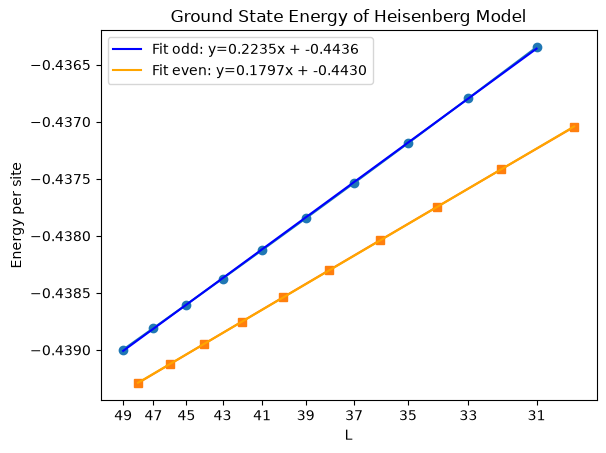

In [22]:
import matplotlib.pyplot as plt
from scipy.stats import linregress

energy_odd = np.real(energies[1::2])
energy_even = np.real(energies[::2])

x_odd = 1 / L[1::2]
x_even = 1 / L[::2]

plt.plot(x_odd, energy_odd, marker='o')
plt.plot(x_even, energy_even, marker='s')
plt.xticks(x_odd, [f'{l}' for l in L[1::2]])


slope_odd, intercept_odd, r_value_odd, p_value_odd, std_err_odd = linregress(x_odd, energy_odd)
plt.plot(x_odd, slope_odd * x_odd + intercept_odd, label=f'Fit odd: y={slope_odd:.4f}x + {intercept_odd:.4f}', color='blue')
slope_even, intercept_even, r_value_even, p_value_even, std_err_even = linregress(x_even, energy_even)
plt.plot(x_even, slope_even * x_even + intercept_even, label=f'Fit even: y={slope_even:.4f}x + {intercept_even:.4f}', color='orange')

plt.xlabel('L')
plt.ylabel('Energy per site')
plt.title('Ground State Energy of Heisenberg Model')
plt.legend()
